In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
X = 6 * np.random.rand(100, 1)-3
y = 0.5 * X**2 + 1.5 * X + 2 + np.random.rand(100, 1)

In [ ]:
plt.scatter(X,y, color = 'r')
plt.show()

In [134]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [136]:
from sklearn.linear_model import LinearRegression

In [138]:
regression = LinearRegression()

In [140]:
regression.fit(X_train,y_train)

LinearRegression()

In [142]:
from sklearn.metrics import r2_score
scorer = r2_score(y_test, regression.predict(X_test))
print(scorer)

0.8312432584342302


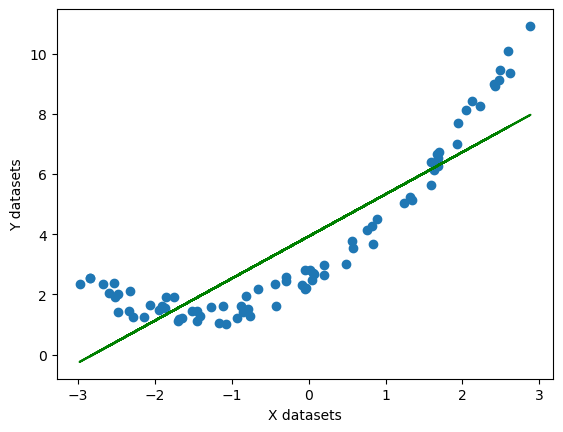

In [144]:
plt.plot(X_train, regression.predict(X_train), color = 'g')
plt.scatter(X_train, y_train)
plt.xlabel('X datasets')
plt.ylabel('Y datasets')
plt.show()

In [146]:
from sklearn.preprocessing import PolynomialFeatures

In [148]:
poly = PolynomialFeatures(degree = 2,include_bias = True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
X_train_poly

In [152]:
from sklearn.metrics import r2_score
regression.fit(X_train_poly,y_train)
y_pred = regression.predict(X_test_poly)
sc = r2_score(y_test, y_pred)
print(sc)

0.9876293732869742


In [154]:
print(regression.coef_)

[[0.         1.49612831 0.50370527]]


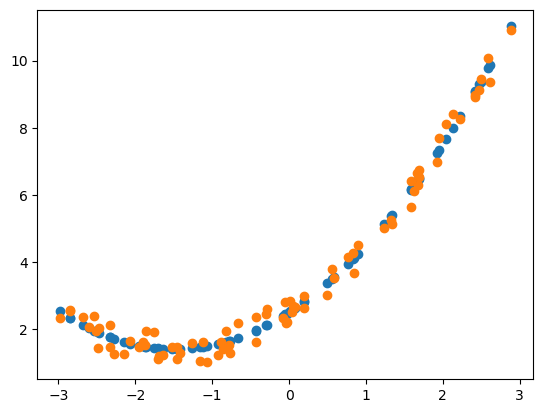

In [156]:
plt.scatter(X_train, regression.predict(X_train_poly))
plt.scatter(X_train,y_train)
plt.show()

In [165]:
poly = PolynomialFeatures(degree = 3,include_bias = True)
X_train_poly1 = poly.fit_transform(X_train)
X_test_poly1 = poly.transform(X_test)

In [167]:
from sklearn.metrics import r2_score
regression.fit(X_train_poly1,y_train)
y_pred = regression.predict(X_test_poly1)
sc = r2_score(y_test, y_pred)
print(sc)

0.987754838743772


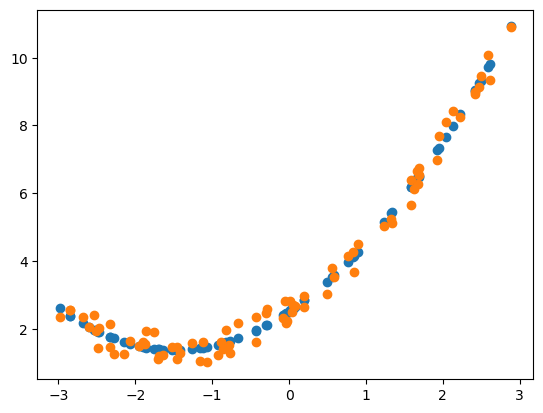

In [169]:
plt.scatter(X_train, regression.predict(X_train_poly1))
plt.scatter(X_train,y_train)
plt.show()

## Building Polynomial Pipeline

In [188]:
from sklearn.pipeline import Pipeline

In [194]:
def polynomial_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)

    poly_features = PolynomialFeatures(degree=degree, include_bias = True)
    lin_reg=LinearRegression()
    poly_regression = Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train)
    y_pred_new = poly_regression.predict(X_new)

#Plotting prediction line
    plt.plot(X_new, y_pred_new, 'r', label="Degree" + str(degree), linewidth=3)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.plot(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4,0,10])
    plt.show()

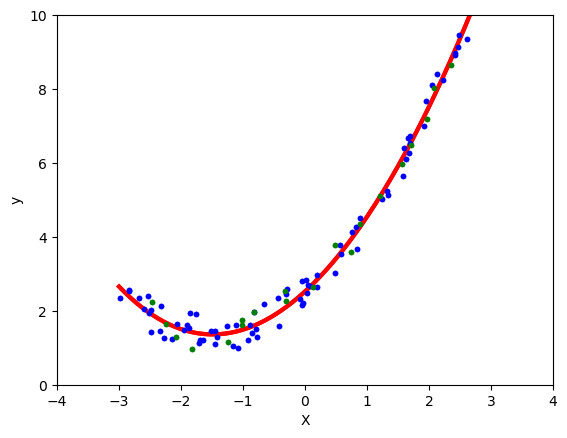

In [196]:
polynomial_regression(4)